# Visión por Computadora I - Trabajo Práctico 2

Yoharlyn Alvarez

In [21]:
%matplotlib inline

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

## Cálculo de la medida de calidad de la imagen

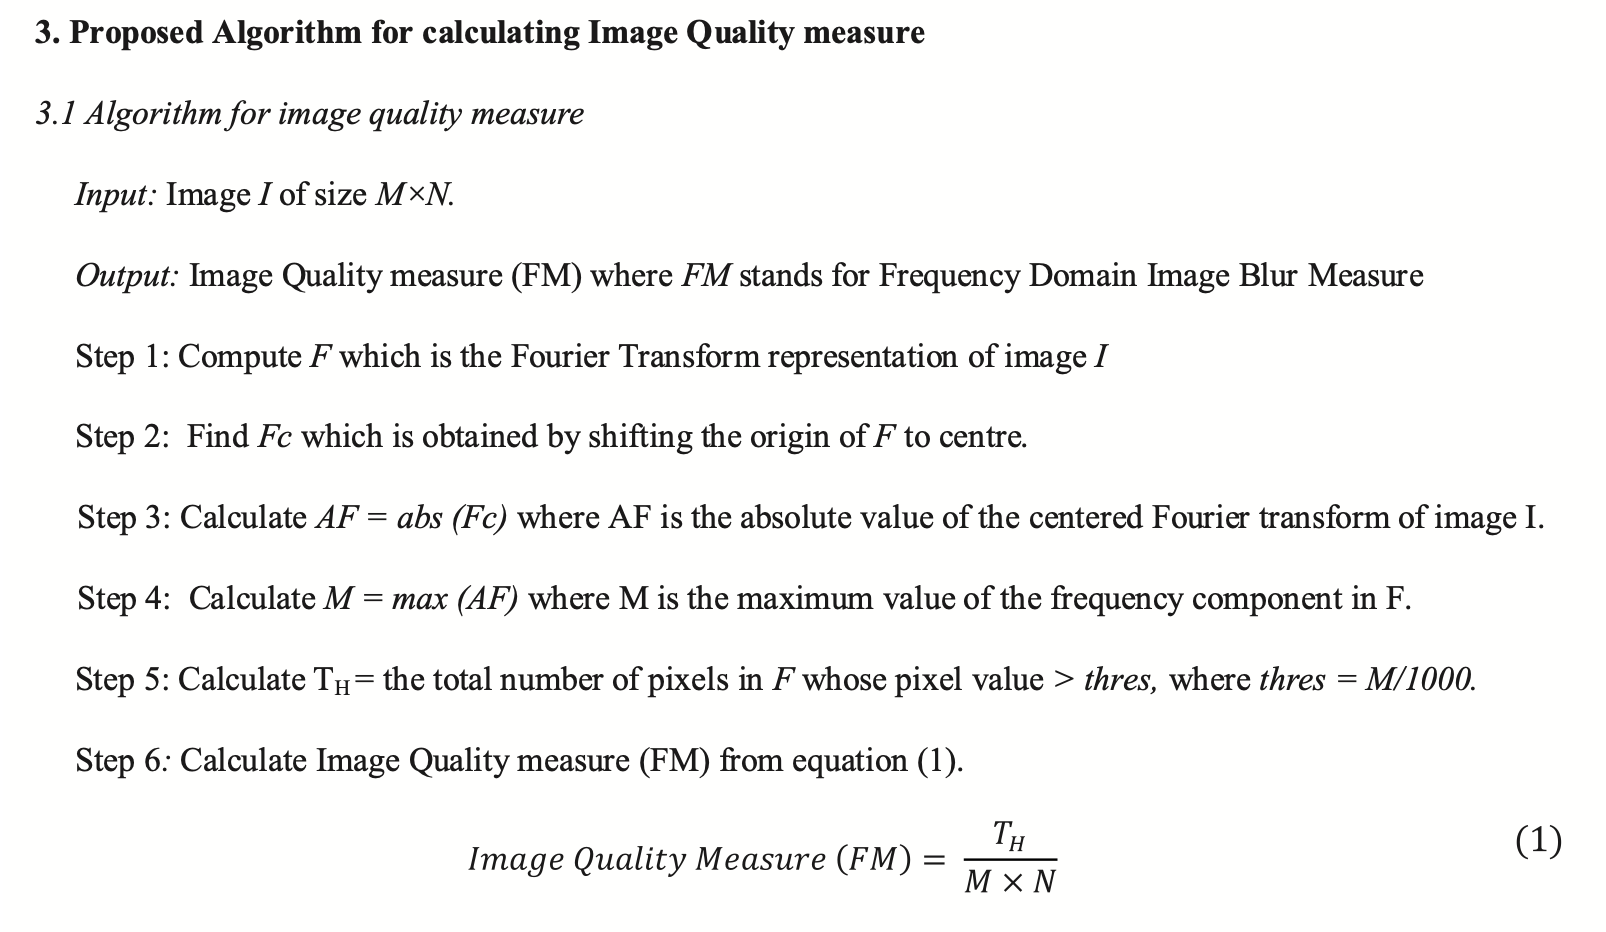

In [22]:
def medida_enfoque_frecuencia(imagen):
    # Convierto la imagen a escala de grises
    if len(imagen.shape) == 3:
        imagen = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)

    # Transformación de Fourier y desplazamiento al centro
    imagen_fft = np.fft.fft2(imagen)
    imagen_fft_centrada = np.fft.fftshift(imagen_fft)

    # Módulo del espectro
    modulo = np.abs(imagen_fft_centrada)
    maximo = np.max(modulo)

    if maximo == 0:
        return 0

    umbral = maximo / 1000
    cantidad_frecuencias = np.count_nonzero(modulo > umbral)
    fm = cantidad_frecuencias / modulo.size

    return fm

## ROI central

In [23]:
def obtener_roi_central(imagen, porcentaje_area=0.10):
    alto, ancho = imagen.shape[:2]

    escala = np.sqrt(porcentaje_area)
    alto_roi = int(alto * escala)
    ancho_roi = int(ancho * escala)

    x = (ancho - ancho_roi) // 2
    y = (alto - alto_roi) // 2

    roi = imagen[y:y + alto_roi, x:x + ancho_roi]
    return roi, (x, y, ancho_roi, alto_roi)

## Procesamiento del video

Para cada frame se calcula `FM` sobre la imagen completa y sobre la ROI central. Luego se usa `np.argmax` para detectar automáticamente el máximo de cada experimento.

In [24]:
video_path = Path('../Material_TPs/TP2/focus_video.mov')

captura_video = cv.VideoCapture(str(video_path))

if not captura_video.isOpened():
    raise FileNotFoundError(f'No se pudo abrir el video: {video_path.resolve()}')

cantidad_frames = int(captura_video.get(cv.CAP_PROP_FRAME_COUNT))
fps = captura_video.get(cv.CAP_PROP_FPS)
ancho = int(captura_video.get(cv.CAP_PROP_FRAME_WIDTH))
alto = int(captura_video.get(cv.CAP_PROP_FRAME_HEIGHT))

print(f'Cantidad de frames: {cantidad_frames}')
print(f'FPS: {fps:.2f}')
print(f'Tamaño: {ancho} x {alto}')

Cantidad de frames: 171
FPS: 29.97
Tamaño: 640 x 360


In [25]:
metricas_frame = []
metricas_roi = []

frame_mejor_frame = None
frame_mejor_roi = None
maximo_frame = -1
maximo_roi = -1

while True:
    ret, frame = captura_video.read()

    if not ret:
        break

    frame_gris = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    roi, coordenadas_roi = obtener_roi_central(frame_gris, porcentaje_area=0.10)

    fm_frame = medida_enfoque_frecuencia(frame_gris)
    fm_roi = medida_enfoque_frecuencia(roi)

    metricas_frame.append(fm_frame)
    metricas_roi.append(fm_roi)

    # Guardo el mejor frame de cada experimento
    if fm_frame > maximo_frame:
        maximo_frame = fm_frame
        frame_mejor_frame = frame.copy()

    if fm_roi > maximo_roi:
        maximo_roi = fm_roi
        frame_mejor_roi = frame.copy()

captura_video.release()

metricas_frame = np.array(metricas_frame)
metricas_roi = np.array(metricas_roi)

print(f'Frames procesados: {len(metricas_frame)}')

Frames procesados: 171


In [26]:
indice_maximo_frame = np.argmax(metricas_frame)
indice_maximo_roi = np.argmax(metricas_roi)

tiempo_maximo_frame = indice_maximo_frame / fps
tiempo_maximo_roi = indice_maximo_roi / fps

print('Experimento 1 - Frame completo')
print(f'  Máximo enfoque: frame {indice_maximo_frame}')
print(f'  Tiempo: {tiempo_maximo_frame:.2f} segundos')
print(f'  FM: {metricas_frame[indice_maximo_frame]:.6f}')

print('\nExperimento 2 - ROI central')
print(f'  Máximo enfoque: frame {indice_maximo_roi}')
print(f'  Tiempo: {tiempo_maximo_roi:.2f} segundos')
print(f'  FM: {metricas_roi[indice_maximo_roi]:.6f}')

Experimento 1 - Frame completo
  Máximo enfoque: frame 109
  Tiempo: 3.64 segundos
  FM: 0.027843

Experimento 2 - ROI central
  Máximo enfoque: frame 111
  Tiempo: 3.70 segundos
  FM: 0.353150


## Curvas de enfoque

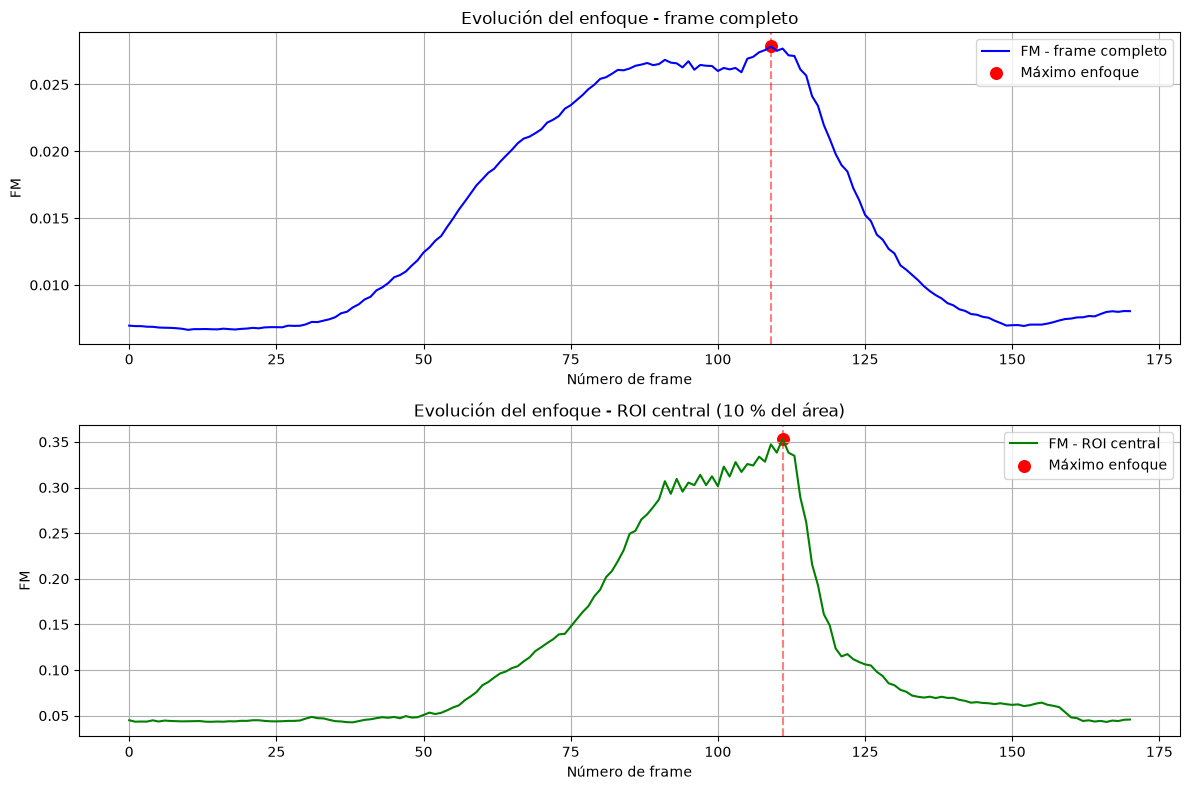

In [27]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(metricas_frame, color='blue', label='FM - frame completo')
plt.scatter(indice_maximo_frame, metricas_frame[indice_maximo_frame],
            color='red', s=70, label='Máximo enfoque')
plt.axvline(indice_maximo_frame, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Número de frame')
plt.ylabel('FM')
plt.title('Evolución del enfoque - frame completo')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(metricas_roi, color='green', label='FM - ROI central')
plt.scatter(indice_maximo_roi, metricas_roi[indice_maximo_roi],
            color='red', s=70, label='Máximo enfoque')
plt.axvline(indice_maximo_roi, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Número de frame')
plt.ylabel('FM')
plt.title('Evolución del enfoque - ROI central (10 % del área)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

## Frames de máximo enfoque

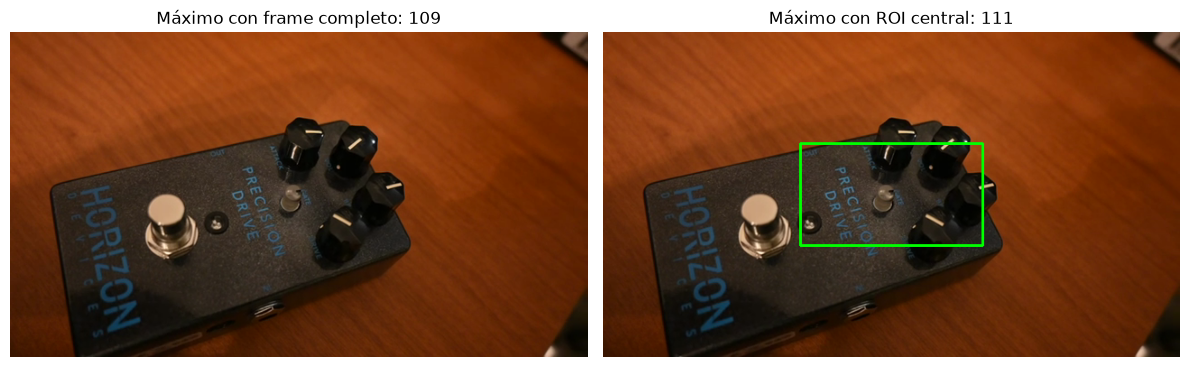

In [28]:
frame_roi_anotado = frame_mejor_roi.copy()
_, (x, y, ancho_roi, alto_roi) = obtener_roi_central(frame_roi_anotado, 0.10)
cv.rectangle(frame_roi_anotado, (x, y), (x + ancho_roi, y + alto_roi),
             (0, 255, 0), 2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(frame_mejor_frame, cv.COLOR_BGR2RGB))
plt.title(f'Máximo con frame completo: {indice_maximo_frame}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(frame_roi_anotado, cv.COLOR_BGR2RGB))
plt.title(f'Máximo con ROI central: {indice_maximo_roi}')
plt.axis('off')

plt.tight_layout()
plt.show()

## Unsharp masking

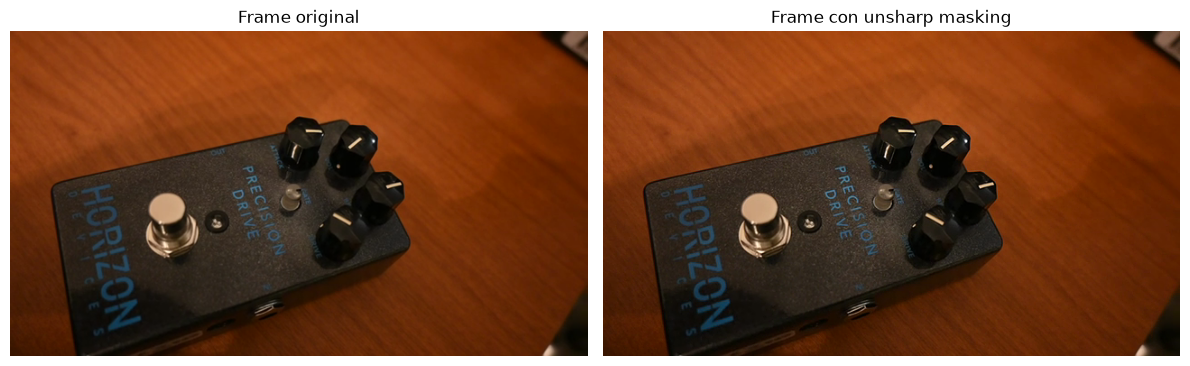

In [29]:
def unsharp_masking(imagen, k=1.5):
    gauss = cv.GaussianBlur(imagen, (7, 7), 0.5)
    imagen_enfocada = cv.addWeighted(imagen, k + 1, gauss, -k, 0)
    return imagen_enfocada

frame_unsharp = unsharp_masking(frame_mejor_roi, k=1.5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(frame_mejor_roi, cv.COLOR_BGR2RGB))
plt.title('Frame original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(frame_unsharp, cv.COLOR_BGR2RGB))
plt.title('Frame con unsharp masking')
plt.axis('off')

plt.tight_layout()
plt.show()

## Conclusiones

Las dos curvas aumentan cuando la imagen gana detalle y alcanzan su máximo en una zona similar del video. La medición sobre el frame completo detectó el máximo enfoque en el frame 109, correspondiente a 3.64 segundos, mientras que la medición sobre la ROI central lo detectó en el frame 111, correspondiente a 3.70 segundos. La diferencia de solamente dos frames muestra que ambos experimentos identifican la misma zona temporal de mayor enfoque.

La ROI central produce valores de `FM` diferentes porque analiza solamente una parte de la escena, pero permite medir el enfoque sobre el objeto central sin que el fondo tenga tanta influencia.

El unsharp masking realza los detalles del frame seleccionado, aunque no recupera información que se haya perdido por un desenfoque fuerte.